In [2]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.datasets import mnist

In [3]:
(x_train, y_train),(x_test, y_test) = mnist.load_data() 

In [5]:
print("X Train: ", x_train.shape)
print("X Test: ", x_test.shape)
print("Y Train: ", y_train.shape)
print("Y Test: ", y_test.shape)

X Train:  (60000, 28, 28)
X Test:  (10000, 28, 28)
Y Train:  (60000,)
Y Test:  (10000,)


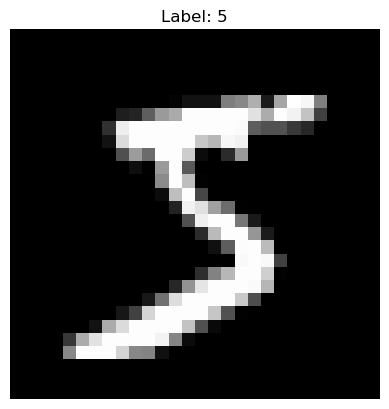

In [7]:
import matplotlib.pyplot as plt

plt.imshow(x_train[0], cmap='gray')
plt.title(f"Label: {y_train[0]}")
plt.axis("off")
plt.show()

In [9]:
print(x_train[0].shape)

(28, 28)


In [12]:
x_train = x_train/255.0
x_test = x_test/255.0

In [13]:
print(x_train.min())
print(x_train.max())

0.0
1.0


In [14]:
x_train = x_train.reshape(-1, 28*28)
x_test = x_test.reshape(-1, 28*28)

In [15]:
print(x_train.shape)
print(x_test.shape)

(60000, 784)
(10000, 784)


In [16]:
model = keras.Sequential([

    keras.Input(shape=(784,)),

    keras.layers.Dense(128, activation='relu'),

    keras.layers.Dense(64, activation='relu'),

    keras.layers.Dense(10, activation='softmax')
])

In [20]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [21]:
history = model.fit(
    x_train,
    y_train, 
    epochs=20,
    batch_size=32,
    validation_split=0.1
)

Epoch 1/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9248 - loss: 0.2546 - val_accuracy: 0.9645 - val_loss: 0.1135
Epoch 2/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9669 - loss: 0.1090 - val_accuracy: 0.9728 - val_loss: 0.0898
Epoch 3/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9761 - loss: 0.0755 - val_accuracy: 0.9733 - val_loss: 0.0948
Epoch 4/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9819 - loss: 0.0570 - val_accuracy: 0.9755 - val_loss: 0.0835
Epoch 5/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9849 - loss: 0.0441 - val_accuracy: 0.9785 - val_loss: 0.0765
Epoch 6/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9888 - loss: 0.0346 - val_accuracy: 0.9743 - val_loss: 0.0993
Epoch 7/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9903 - loss: 0.0292 - val_accuracy: 0.9735 - val_loss: 0.1056
Epoch 8/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9913 - loss: 0.0261 - 

In [22]:
test_loss, test_accuracy  = model.evaluate(x_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9799 - loss: 0.1111


In [23]:
print("Test Accuracy: ", test_accuracy)

Test Accuracy:  0.9799000024795532


In [25]:
predictions = model.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [26]:
print(predictions[:5])

[[1.2148719e-20 1.3142097e-15 2.8119719e-15 2.5106256e-12 2.1478219e-22
  8.4430503e-21 5.2274657e-31 1.0000000e+00 2.8611794e-14 1.1298730e-14]
 [7.7580873e-24 4.0217069e-19 1.0000000e+00 9.0776149e-21 9.6258217e-32
  1.2876249e-24 8.8452743e-20 4.3439717e-21 4.9989963e-16 1.5119279e-26]
 [9.7596796e-14 9.9999976e-01 5.0359605e-10 5.6037216e-14 3.1458057e-08
  7.9326228e-15 2.4882554e-13 1.7915436e-07 2.3235790e-08 1.9620621e-11]
 [1.0000000e+00 9.3034275e-19 7.7041781e-16 4.9738799e-19 1.0777174e-21
  2.5535637e-20 6.8994385e-12 2.7053950e-13 1.2650724e-17 1.2571587e-17]
 [6.2315745e-13 1.0163011e-17 2.4807694e-16 2.8084501e-19 9.9999988e-01
  2.7007389e-17 7.0926920e-14 1.3896422e-11 1.0408742e-17 8.2260918e-08]]


In [27]:
import numpy as np

predicted_labels = np.argmax(predictions, axis=1)

print("Predicted: ",predicted_labels[:5])
print("Actual: ",y_test[:5])

Predicted:  [7 2 1 0 4]
Actual:  [7 2 1 0 4]


In [28]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 128)                 │         100,480 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 10)                  │             650 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 328,160 (1.25 MB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 218,774 (854.59 KB)

In [30]:
print("Best Training Accuracy: ",max(history.history['accuracy']))
print("Best validation Accuracy: ",max(history.history['val_accuracy']))

Best Training Accuracy:  0.9968147873878479
Best validation Accuracy:  0.9810000061988831


In [32]:
print("Epochs: ",max(history.history['loss']))

Epochs:  0.25458472967147827


In [33]:
print("Best Validation Accuracy: ",max(history.history['val_accuracy']))
print("Best Validation Loss: ",max(history.history['val_loss']))

Best Validation Accuracy:  0.9810000061988831
Best Validation Loss:  0.12441194802522659
